In [1]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/Maternal__Child__and_Adolescent_Health_Needs_Assessment__2023-2024.csv")
df.head(5)

,Age_group,Sex,Topic,Data_source,Health_condition-Data_source,Period,Year,Denominator,Denominator_is,Number_with_outcome,...,Race_ethnicity,Rate_title,Trend_title,Filter_1000_or_more,Sort_1000_or_more,Primary_Neighborhood,Cause of death rank,Death_tooltip,Latest_data,Unique_row_id
0,0to12months,ALL,HEALTH CONDITION,CDPH BIRTH RECORDS,ASSISTED VENTILATION FOR >6 HOURS - CDPH BIRTH...,2019,2019.0,8307.0,TOTAL BIRTHS,25.0,...,ALL,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,20-50,4,All,NaN,NaN,NaN,5577
1,0to12months,ALL,HEALTH CONDITION,CDPH BIRTH RECORDS,ASSISTED VENTILATION FOR >6 HOURS - CDPH BIRTH...,2020,2020.0,7890.0,TOTAL BIRTHS,43.0,...,ALL,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,20-50,4,All,NaN,NaN,NaN,19728
2,0to12months,ALL,HEALTH CONDITION,CDPH BIRTH RECORDS,ASSISTED VENTILATION FOR >6 HOURS - CDPH BIRTH...,2021,2021.0,7413.0,TOTAL BIRTHS,46.0,...,ALL,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,20-50,4,All,NaN,NaN,NaN,21267
3,0to12months,ALL,HEALTH CONDITION,CDPH BIRTH RECORDS,ASSISTED VENTILATION FOR >6 HOURS - CDPH BIRTH...,2022,2022.0,7049.0,TOTAL BIRTHS,24.0,...,ALL,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,20-50,4,All,NaN,NaN,NaN,4433
4,0to12months,ALL,HEALTH CONDITION,CDPH BIRTH RECORDS,ASSISTED VENTILATION FOR >6 HOURS - CDPH BIRTH...,2014-2016,NaN,6673.0,TOTAL BIRTHS,21.0,...,ALL,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,20-50,4,All,NaN,NaN,NaN,437


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62714 entries, 0 to 62713
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age_group                     62713 non-null  object 
 1   Sex                           62714 non-null  object 
 2   Topic                         62713 non-null  object 
 3   Data_source                   62714 non-null  object 
 4   Health_condition-Data_source  62713 non-null  object 
 5   Period                        62713 non-null  object 
 6   Year                          32079 non-null  float64
 7   Denominator                   62526 non-null  float64
 8   Denominator_is                62594 non-null  object 
 9   Number_with_outcome           62595 non-null  float64
 10  Numerator_is                  62699 non-null  object 
 11  Rate_95CI                     62566 non-null  object 
 12  Rate_SF_pop                   62566 non-null  float64
 13  C

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age_group,62713,46,PREGNANT,8683,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,62714,5,ALL,29576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Topic,62713,11,HEALTH CONDITION,25788,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data_source,62714,17,ER VISITS,27028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Health_condition-Data_source,62713,442,ALL ER VISITS - ER VISITS,3991,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Period,62713,57,2017-2021,10172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,32079.0,NaN,NaN,NaN,2017.86474,3.447658,1997.0,2017.0,2019.0,2020.0,2025.0
Denominator,62526.0,NaN,NaN,NaN,42738.214919,130897.162331,23.0,1116.0,7184.0,26367.0,2804452.0
Denominator_is,62594,25,CENSUS ESTIMATE,41722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number_with_outcome,62595.0,NaN,NaN,NaN,461.820491,2624.301571,14.0,36.0,74.0,221.0,176888.0


In [ ]:
df.shape

(62714, 28)

In [ ]:
#missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Age_group                           1
Sex                                 0
Topic                               1
Data_source                         0
Health_condition-Data_source        1
Period                              1
Year                            30635
Denominator                       188
Denominator_is                    120
Number_with_outcome               119
Numerator_is                       15
Rate_95CI                         148
Rate_SF_pop                       148
CI_low                            209
CI_high                           209
Rate_is                           124
Insurance                           1
Zip_code                            1
Race_ethnicity                      1
Rate_title                          1
Trend_title                        24
Filter_1000_or_more                 0
Sort_1000_or_more                   0
Primary_Neighborhood               10
Cause of death rank             62676
Death_tooltip                   6

In [ ]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-1164486689.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-1164486689.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
missing_values_after_cleaning = df.isnull().sum()
print("Missing Values:\n", missing_values_after_cleaning)

Missing Values:
 Age_group                       0
Sex                             0
Topic                           0
Data_source                     0
Health_condition-Data_source    0
Period                          0
Year                            0
Denominator                     0
Denominator_is                  0
Number_with_outcome             0
Numerator_is                    0
Rate_95CI                       0
Rate_SF_pop                     0
CI_low                          0
CI_high                         0
Rate_is                         0
Insurance                       0
Zip_code                        0
Race_ethnicity                  0
Rate_title                      0
Trend_title                     0
Filter_1000_or_more             0
Sort_1000_or_more               0
Primary_Neighborhood            0
Cause of death rank             0
Death_tooltip                   0
Latest_data                     0
Unique_row_id                   0
dtype: int64


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Year' in numerical_cols:
    numerical_cols.remove('Year')
    categorical_cols.append('Year')

column_data = {
    'Categorical Columns': pd.Series(categorical_cols),
    'Numerical Columns': pd.Series(numerical_cols)
}
column_table = pd.DataFrame(column_data)
display(column_table)

,Categorical Columns,Numerical Columns
0,Age_group,Denominator
1,Sex,Number_with_outcome
2,Topic,Rate_SF_pop
3,Data_source,CI_low
4,Health_condition-Data_source,CI_high
5,Period,Sort_1000_or_more
6,Denominator_is,Cause of death rank
7,Numerator_is,Latest_data
8,Rate_95CI,Unique_row_id
9,Rate_is,NaN


In [ ]:
print(column_table.iloc[:, :1])

             Categorical Columns
0                      Age_group
1                            Sex
2                          Topic
3                    Data_source
4   Health_condition-Data_source
5                         Period
6                 Denominator_is
7                   Numerator_is
8                      Rate_95CI
9                        Rate_is
10                     Insurance
11                      Zip_code
12                Race_ethnicity
13                    Rate_title
14                   Trend_title
15           Filter_1000_or_more
16          Primary_Neighborhood
17                 Death_tooltip
18                          Year


In [ ]:
#Detecting outliers using IQR method
import pandas as pd

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = ((df[numerical_cols] < lower_bound) | (df[numerical_cols] > upper_bound))
outlier_count = outlier_mask.sum()
print("\nOutliers detected per column:\n", outlier_count)

df_clean = df[~outlier_mask.any(axis=1)]

print("\nBefore Cleaning:", df.shape)
print("After Cleaning:", df_clean.shape)

removed_pct = round((1 - len(df_clean) / len(df)) * 100, 2)
print(f"\nPercentage of rows removed: {removed_pct}%")


Outliers detected per column:
 Denominator            8392
Number_with_outcome    8475
Rate_SF_pop            6530
CI_low                 7377
CI_high                5584
Sort_1000_or_more         8
Cause of death rank      30
Latest_data               0
Unique_row_id             0
dtype: int64

Before Cleaning: (62714, 28)
After Cleaning: (43742, 28)

Percentage of rows removed: 30.25%


In [ ]:
df_clean.head()
df=df_clean

In [ ]:
# Encoding categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,Age_group,Sex,Topic,Data_source,Health_condition-Data_source,Period,Year,Denominator,Denominator_is,Number_with_outcome,...,Race_ethnicity,Rate_title,Trend_title,Filter_1000_or_more,Sort_1000_or_more,Primary_Neighborhood,Cause of death rank,Death_tooltip,Latest_data,Unique_row_id
0,0,0,5,0,32,43,22,8307.0,18,25.0,...,0,1099,210,3,4,1,3.0,1,1.0,5577
1,0,0,5,0,32,47,23,7890.0,18,43.0,...,0,1100,210,3,4,1,3.0,1,1.0,19728
2,0,0,5,0,32,50,24,7413.0,18,46.0,...,0,1102,210,3,4,1,3.0,1,1.0,21267
3,0,0,5,0,32,52,25,7049.0,18,24.0,...,0,1103,210,3,4,1,3.0,1,1.0,4433
4,0,0,5,0,32,27,22,6673.0,18,21.0,...,0,1097,210,3,4,1,3.0,1,1.0,437


In [ ]:
# Standardizing numeric data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df_scaled.head()

,Age_group,Sex,Topic,Data_source,Health_condition-Data_source,Period,Year,Denominator,Denominator_is,Number_with_outcome,...,Race_ethnicity,Rate_title,Trend_title,Filter_1000_or_more,Sort_1000_or_more,Primary_Neighborhood,Cause of death rank,Death_tooltip,Latest_data,Unique_row_id
0,0,0,5,0,32,43,22,-0.198251,18,-0.704734,...,0,1099,210,3,-0.912877,1,0.0,1,0.0,-1.283738
1,0,0,5,0,32,47,23,-0.227846,18,-0.510436,...,0,1100,210,3,-0.912877,1,0.0,1,0.0,-0.354644
2,0,0,5,0,32,50,24,-0.261700,18,-0.478053,...,0,1102,210,3,-0.912877,1,0.0,1,0.0,-0.253600
3,0,0,5,0,32,52,25,-0.287534,18,-0.715529,...,0,1103,210,3,-0.912877,1,0.0,1,0.0,-1.358848
4,0,0,5,0,32,27,22,-0.314219,18,-0.747912,...,0,1097,210,3,-0.912877,1,0.0,1,0.0,-1.621209


In [ ]:
df=df_scaled

In [ ]:
df.head()

,Age_group,Sex,Topic,Data_source,Health_condition-Data_source,Period,Year,Denominator,Denominator_is,Number_with_outcome,...,Race_ethnicity,Rate_title,Trend_title,Filter_1000_or_more,Sort_1000_or_more,Primary_Neighborhood,Cause of death rank,Death_tooltip,Latest_data,Unique_row_id
0,0,0,5,0,32,43,22,-0.198251,18,-0.704734,...,0,1099,210,3,-0.912877,1,0.0,1,0.0,-1.283738
1,0,0,5,0,32,47,23,-0.227846,18,-0.510436,...,0,1100,210,3,-0.912877,1,0.0,1,0.0,-0.354644
2,0,0,5,0,32,50,24,-0.261700,18,-0.478053,...,0,1102,210,3,-0.912877,1,0.0,1,0.0,-0.253600
3,0,0,5,0,32,52,25,-0.287534,18,-0.715529,...,0,1103,210,3,-0.912877,1,0.0,1,0.0,-1.358848
4,0,0,5,0,32,27,22,-0.314219,18,-0.747912,...,0,1097,210,3,-0.912877,1,0.0,1,0.0,-1.621209


In [ ]:
#Summary Statistics
summary_stats = df_scaled[numerical_cols].describe().T
summary_stats['skewness'] = df_scaled[numerical_cols].skew()
summary_stats['kurtosis'] = df_scaled[numerical_cols].kurt()
summary_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Denominator,43742.0,5.198063e-18,1.000011,-0.785760,-0.717130,-0.416349,0.337236,3.715804,1.682854,2.281773
Number_with_outcome,43742.0,-9.746368e-17,1.000011,-0.823472,-0.639968,-0.402493,0.180401,4.400986,2.123292,4.375858
Rate_SF_pop,43742.0,-6.497579e-17,1.000011,-0.861403,-0.702156,-0.419049,0.312310,3.744977,1.616501,1.852440
CI_low,43742.0,-3.378741e-17,1.000011,-0.831930,-0.687867,-0.421350,0.282758,3.706057,1.708597,2.233492
CI_high,43742.0,5.198063e-17,1.000011,-0.892240,-0.710304,-0.415274,0.337053,3.720067,1.553651,1.641557
Sort_1000_or_more,43742.0,1.416472e-16,1.000011,-4.409263,-0.912877,0.252585,1.418047,3.748972,0.277489,-0.833460
Cause of death rank,43742.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Latest_data,43742.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Unique_row_id,43742.0,-7.407240e-17,1.000011,-1.649309,-0.863837,-0.046686,0.826339,2.467634,0.137556,-1.123286


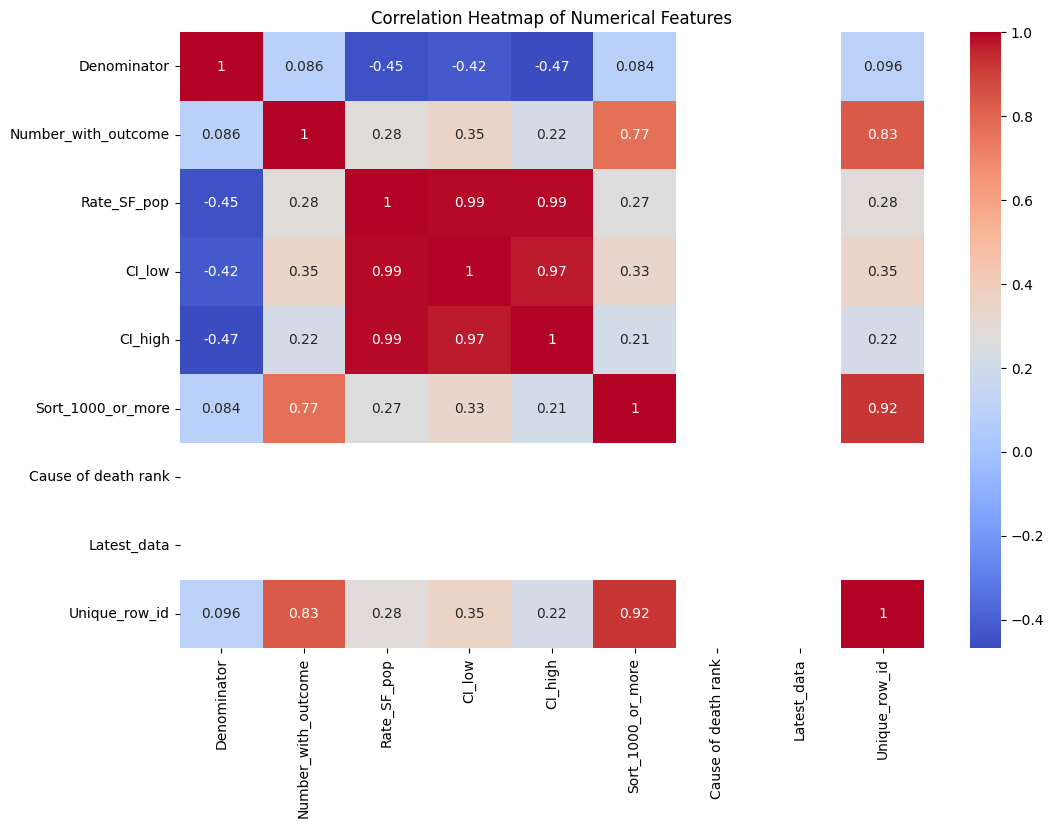

In [ ]:
#correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(df_scaled[numerical_cols].corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [ ]:
#df=df.drop(['Cause of death rank', 'Latest_data'], axis=1)
#df

,Age_group,Sex,Topic,Data_source,Health_condition-Data_source,Period,Year,Denominator,Denominator_is,Number_with_outcome,...,Insurance,Zip_code,Race_ethnicity,Rate_title,Trend_title,Filter_1000_or_more,Sort_1000_or_more,Primary_Neighborhood,Death_tooltip,Unique_row_id
0,0,0,5,0,32,43,22,-0.198251,18,-0.704734,...,0,28,0,1099,210,3,-0.912877,1,1,-1.283738
1,0,0,5,0,32,47,23,-0.227846,18,-0.510436,...,0,28,0,1100,210,3,-0.912877,1,1,-0.354644
2,0,0,5,0,32,50,24,-0.261700,18,-0.478053,...,0,28,0,1102,210,3,-0.912877,1,1,-0.253600
3,0,0,5,0,32,52,25,-0.287534,18,-0.715529,...,0,28,0,1103,210,3,-0.912877,1,1,-1.358848
4,0,0,5,0,32,27,22,-0.314219,18,-0.747912,...,4,28,0,1097,210,3,-0.912877,1,1,-1.621209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62709,43,2,5,11,384,39,22,2.085356,12,0.936005,...,0,28,0,6603,1228,1,1.418047,1,1,1.274209
62710,43,2,5,11,384,48,22,-0.606200,12,-0.715529,...,0,28,4,6607,1228,3,-0.912877,1,1,-1.295162
62711,43,2,5,11,384,48,22,-0.563687,12,-0.553614,...,4,28,0,6607,1228,3,-0.912877,1,1,-0.472693
62712,43,2,5,11,384,48,22,0.283652,12,-0.348521,...,0,28,0,6607,1228,4,0.252585,1,1,0.099497


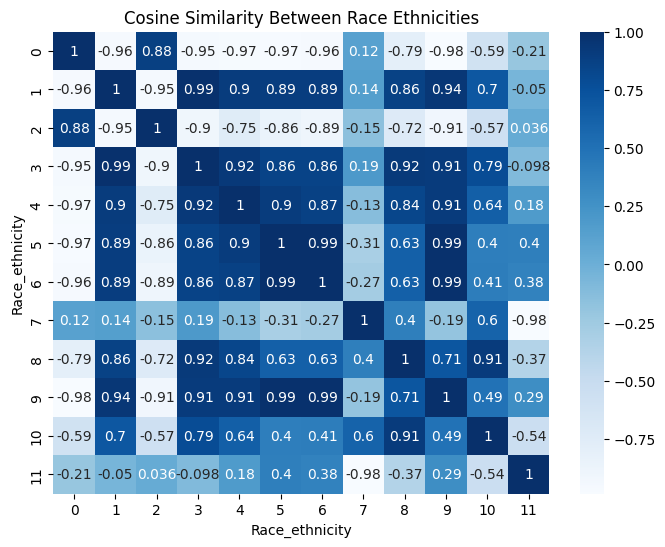

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


group_means = df.groupby('Race_ethnicity')[numerical_cols].mean()

similarity_matrix = pd.DataFrame(
    cosine_similarity(group_means),
    index=group_means.index,
    columns=group_means.index
)

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, annot=True, cmap='Blues')
plt.title("Cosine Similarity Between Race Ethnicities")
plt.show()

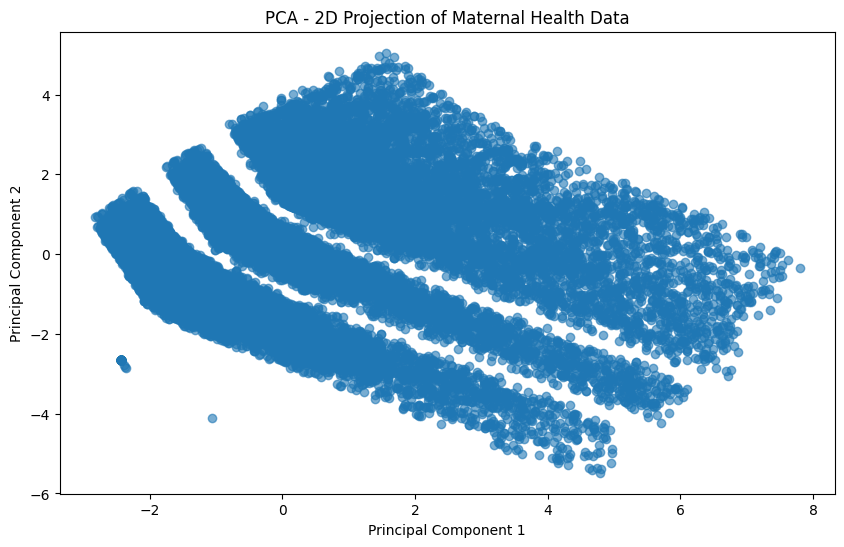

Explained Variance Ratio: [0.48571274 0.27043087]


In [ ]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled[numerical_cols])

plt.figure(figsize=(10,6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], alpha=0.6)
plt.title("PCA - 2D Projection of Maternal Health Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

In [ ]:
# Separate target variable
target = df_scaled['Rate_SF_pop']  # This is your outcome variable
features = df_scaled.drop(columns=['Rate_SF_pop'])

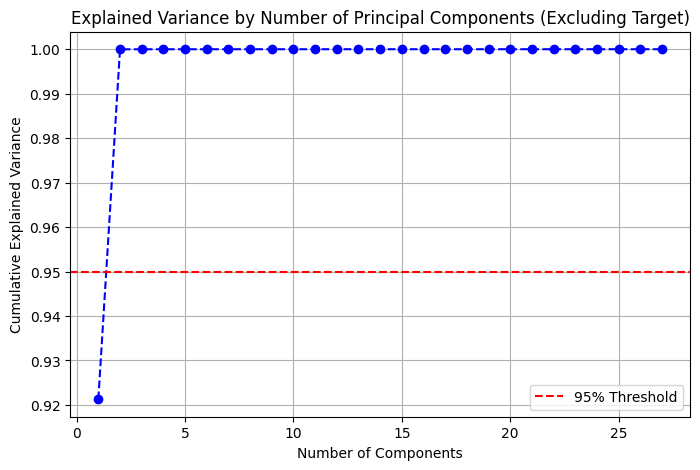

Number of components explaining 95% variance: 2


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA on all numerical features except the target
pca_full = PCA()
pca_full.fit(features)

# Explained variance ratio
explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot the explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', linestyle='--', color='b')
plt.title("Explained Variance by Number of Principal Components (Excluding Target)")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.legend()
plt.show()

# Choose the number of components that explain 95% variance
n_components_95 = np.argmax(explained_variance >= 0.95) + 1
print(f"Number of components explaining 95% variance: {n_components_95}")


In [ ]:
# Apply PCA
pca = PCA(n_components=n_components_95)
reduced_features = pca.fit_transform(features)

# Convert to DataFrame
pca_df = pd.DataFrame(reduced_features, columns=[f'PC{i+1}' for i in range(n_components_95)])

# Add back the target variable
pca_df['Rate_SF_pop'] = target.reset_index(drop=True)

print("PCA-reduced dataset shape (with target added back):", pca_df.shape)
display(pca_df.head())


PCA-reduced dataset shape (with target added back): (43742, 3)


,PC1,PC2,Rate_SF_pop
0,-9408.434417,-2313.023056,-0.849607
1,-9393.432353,-2312.081682,-0.837811
2,-9387.427867,-2310.136918,-0.831913
3,-9407.425643,-2309.109188,-0.849607
4,-9408.438177,-2314.973509,-0.849607


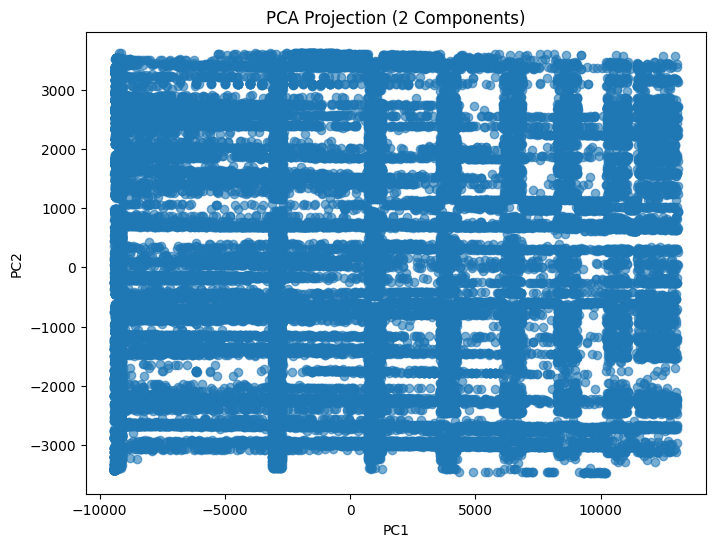

In [ ]:
if n_components_95 == 2:
    plt.figure(figsize=(8,6))
    plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6)
    plt.title("PCA Projection (2 Components)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

elif n_components_95 >= 3:
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], alpha=0.6)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title("PCA Projection (3 Components)")
    plt.show()

In [ ]:
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43742 entries, 0 to 43741
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age_group                     43742 non-null  int64  
 1   Sex                           43742 non-null  int64  
 2   Topic                         43742 non-null  int64  
 3   Data_source                   43742 non-null  int64  
 4   Health_condition-Data_source  43742 non-null  int64  
 5   Period                        43742 non-null  int64  
 6   Denominator_is                43742 non-null  int64  
 7   Numerator_is                  43742 non-null  int64  
 8   Rate_95CI                     43742 non-null  int64  
 9   Rate_is                       43742 non-null  int64  
 10  Insurance                     43742 non-null  int64  
 11  Zip_code                      43742 non-null  int64  
 12  Race_ethnicity                43742 non-null  int64  
 13  R

In [ ]:
df = pd.concat([df, df_reduced[['PC1', 'PC2']]], axis=1)
df.head()

,Age_group,Sex,Topic,Data_source,Health_condition-Data_source,Period,Year,Denominator,Denominator_is,Number_with_outcome,...,Trend_title,Filter_1000_or_more,Sort_1000_or_more,Primary_Neighborhood,Cause of death rank,Death_tooltip,Latest_data,Unique_row_id,PC1,PC2
0,0.0,0.0,5.0,0.0,32.0,43.0,22.0,-0.198251,18.0,-0.704734,...,210.0,3.0,-0.912877,1.0,0.0,1.0,0.0,-1.283738,-9408.434417,-2313.023056
1,0.0,0.0,5.0,0.0,32.0,47.0,23.0,-0.227846,18.0,-0.510436,...,210.0,3.0,-0.912877,1.0,0.0,1.0,0.0,-0.354644,-9393.432353,-2312.081682
2,0.0,0.0,5.0,0.0,32.0,50.0,24.0,-0.261700,18.0,-0.478053,...,210.0,3.0,-0.912877,1.0,0.0,1.0,0.0,-0.253600,-9387.427867,-2310.136918
3,0.0,0.0,5.0,0.0,32.0,52.0,25.0,-0.287534,18.0,-0.715529,...,210.0,3.0,-0.912877,1.0,0.0,1.0,0.0,-1.358848,-9407.425643,-2309.109188
4,0.0,0.0,5.0,0.0,32.0,27.0,22.0,-0.314219,18.0,-0.747912,...,210.0,3.0,-0.912877,1.0,0.0,1.0,0.0,-1.621209,-9408.438177,-2314.973509


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58689 entries, 0 to 43736
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age_group                     43742 non-null  float64
 1   Sex                           43742 non-null  float64
 2   Topic                         43742 non-null  float64
 3   Data_source                   43742 non-null  float64
 4   Health_condition-Data_source  43742 non-null  float64
 5   Period                        43742 non-null  float64
 6   Year                          43742 non-null  float64
 7   Denominator                   43742 non-null  float64
 8   Denominator_is                43742 non-null  float64
 9   Number_with_outcome           43742 non-null  float64
 10  Numerator_is                  43742 non-null  float64
 11  Rate_95CI                     43742 non-null  float64
 12  Rate_SF_pop                   43742 non-null  float64
 13  CI_low

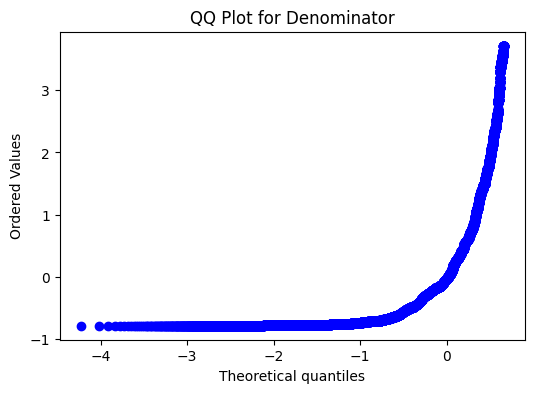

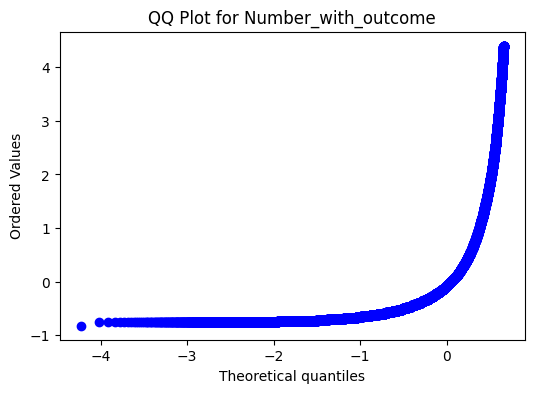

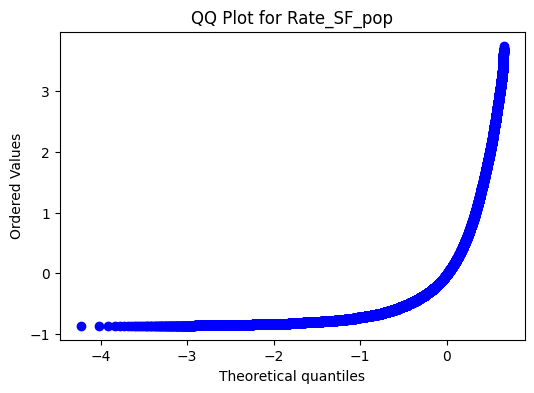

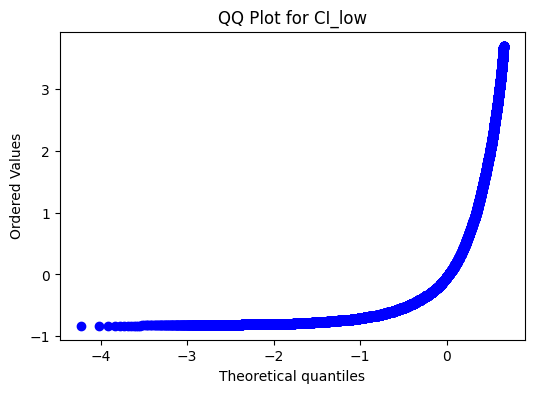

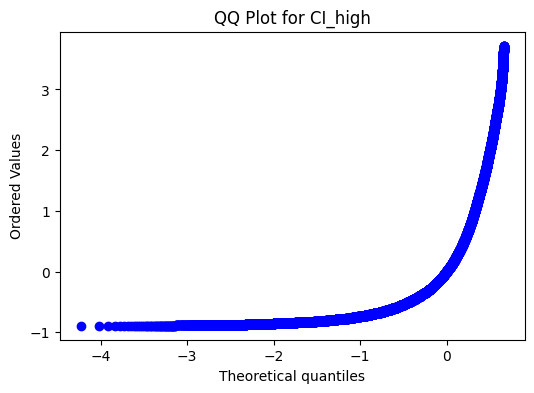

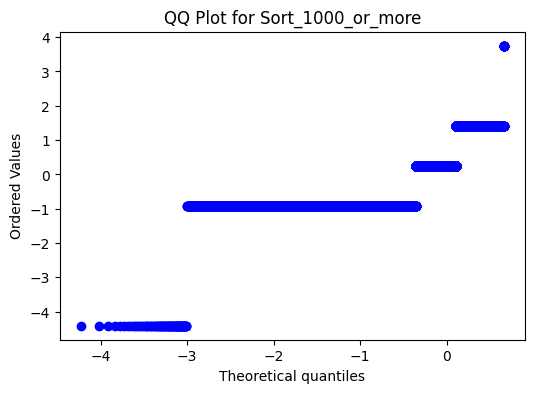

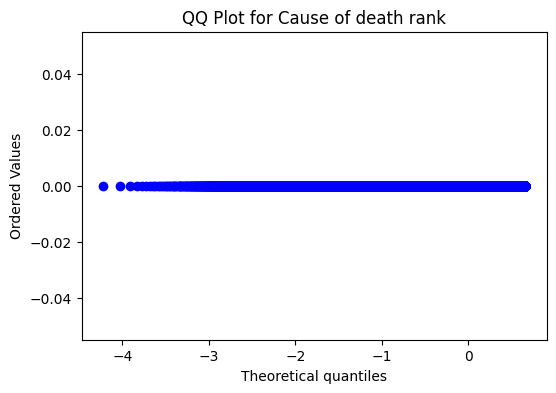

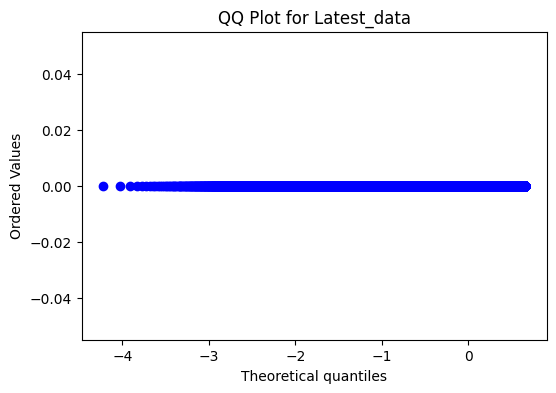

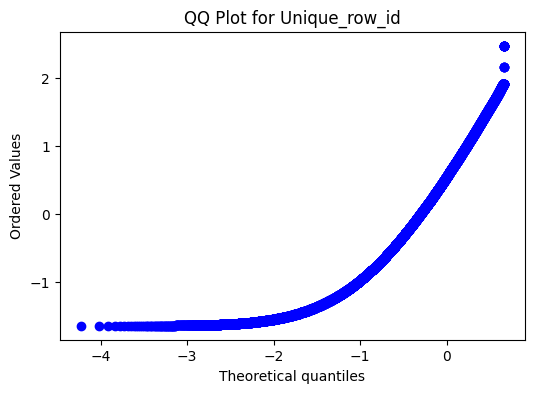

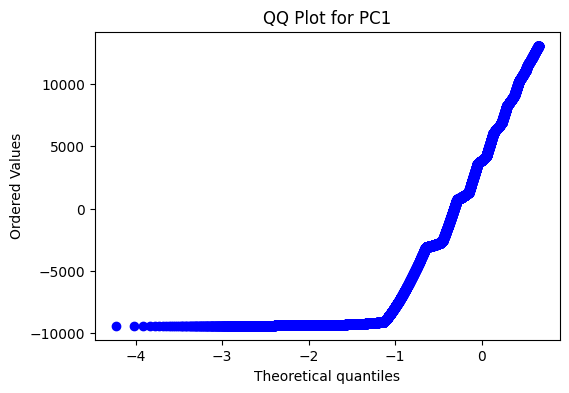

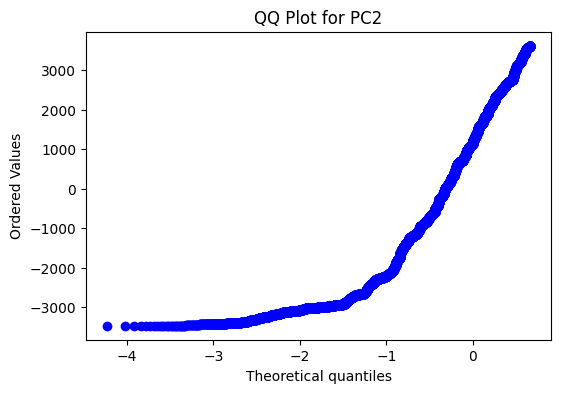

In [ ]:
#Advanced Data Analysis
#QQ plots
import scipy.stats as stats
import matplotlib.pyplot as plt

numerical_cols = [
    'Denominator',
    'Number_with_outcome',
    'Rate_SF_pop',
    'CI_low',
    'CI_high',
    'Sort_1000_or_more',
    'Cause of death rank',
    'Latest_data',
    'Unique_row_id',
    'PC1',
    'PC2'
]


for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f"QQ Plot for {col}")
    plt.show()


<Figure size 1000x600 with 0 Axes>

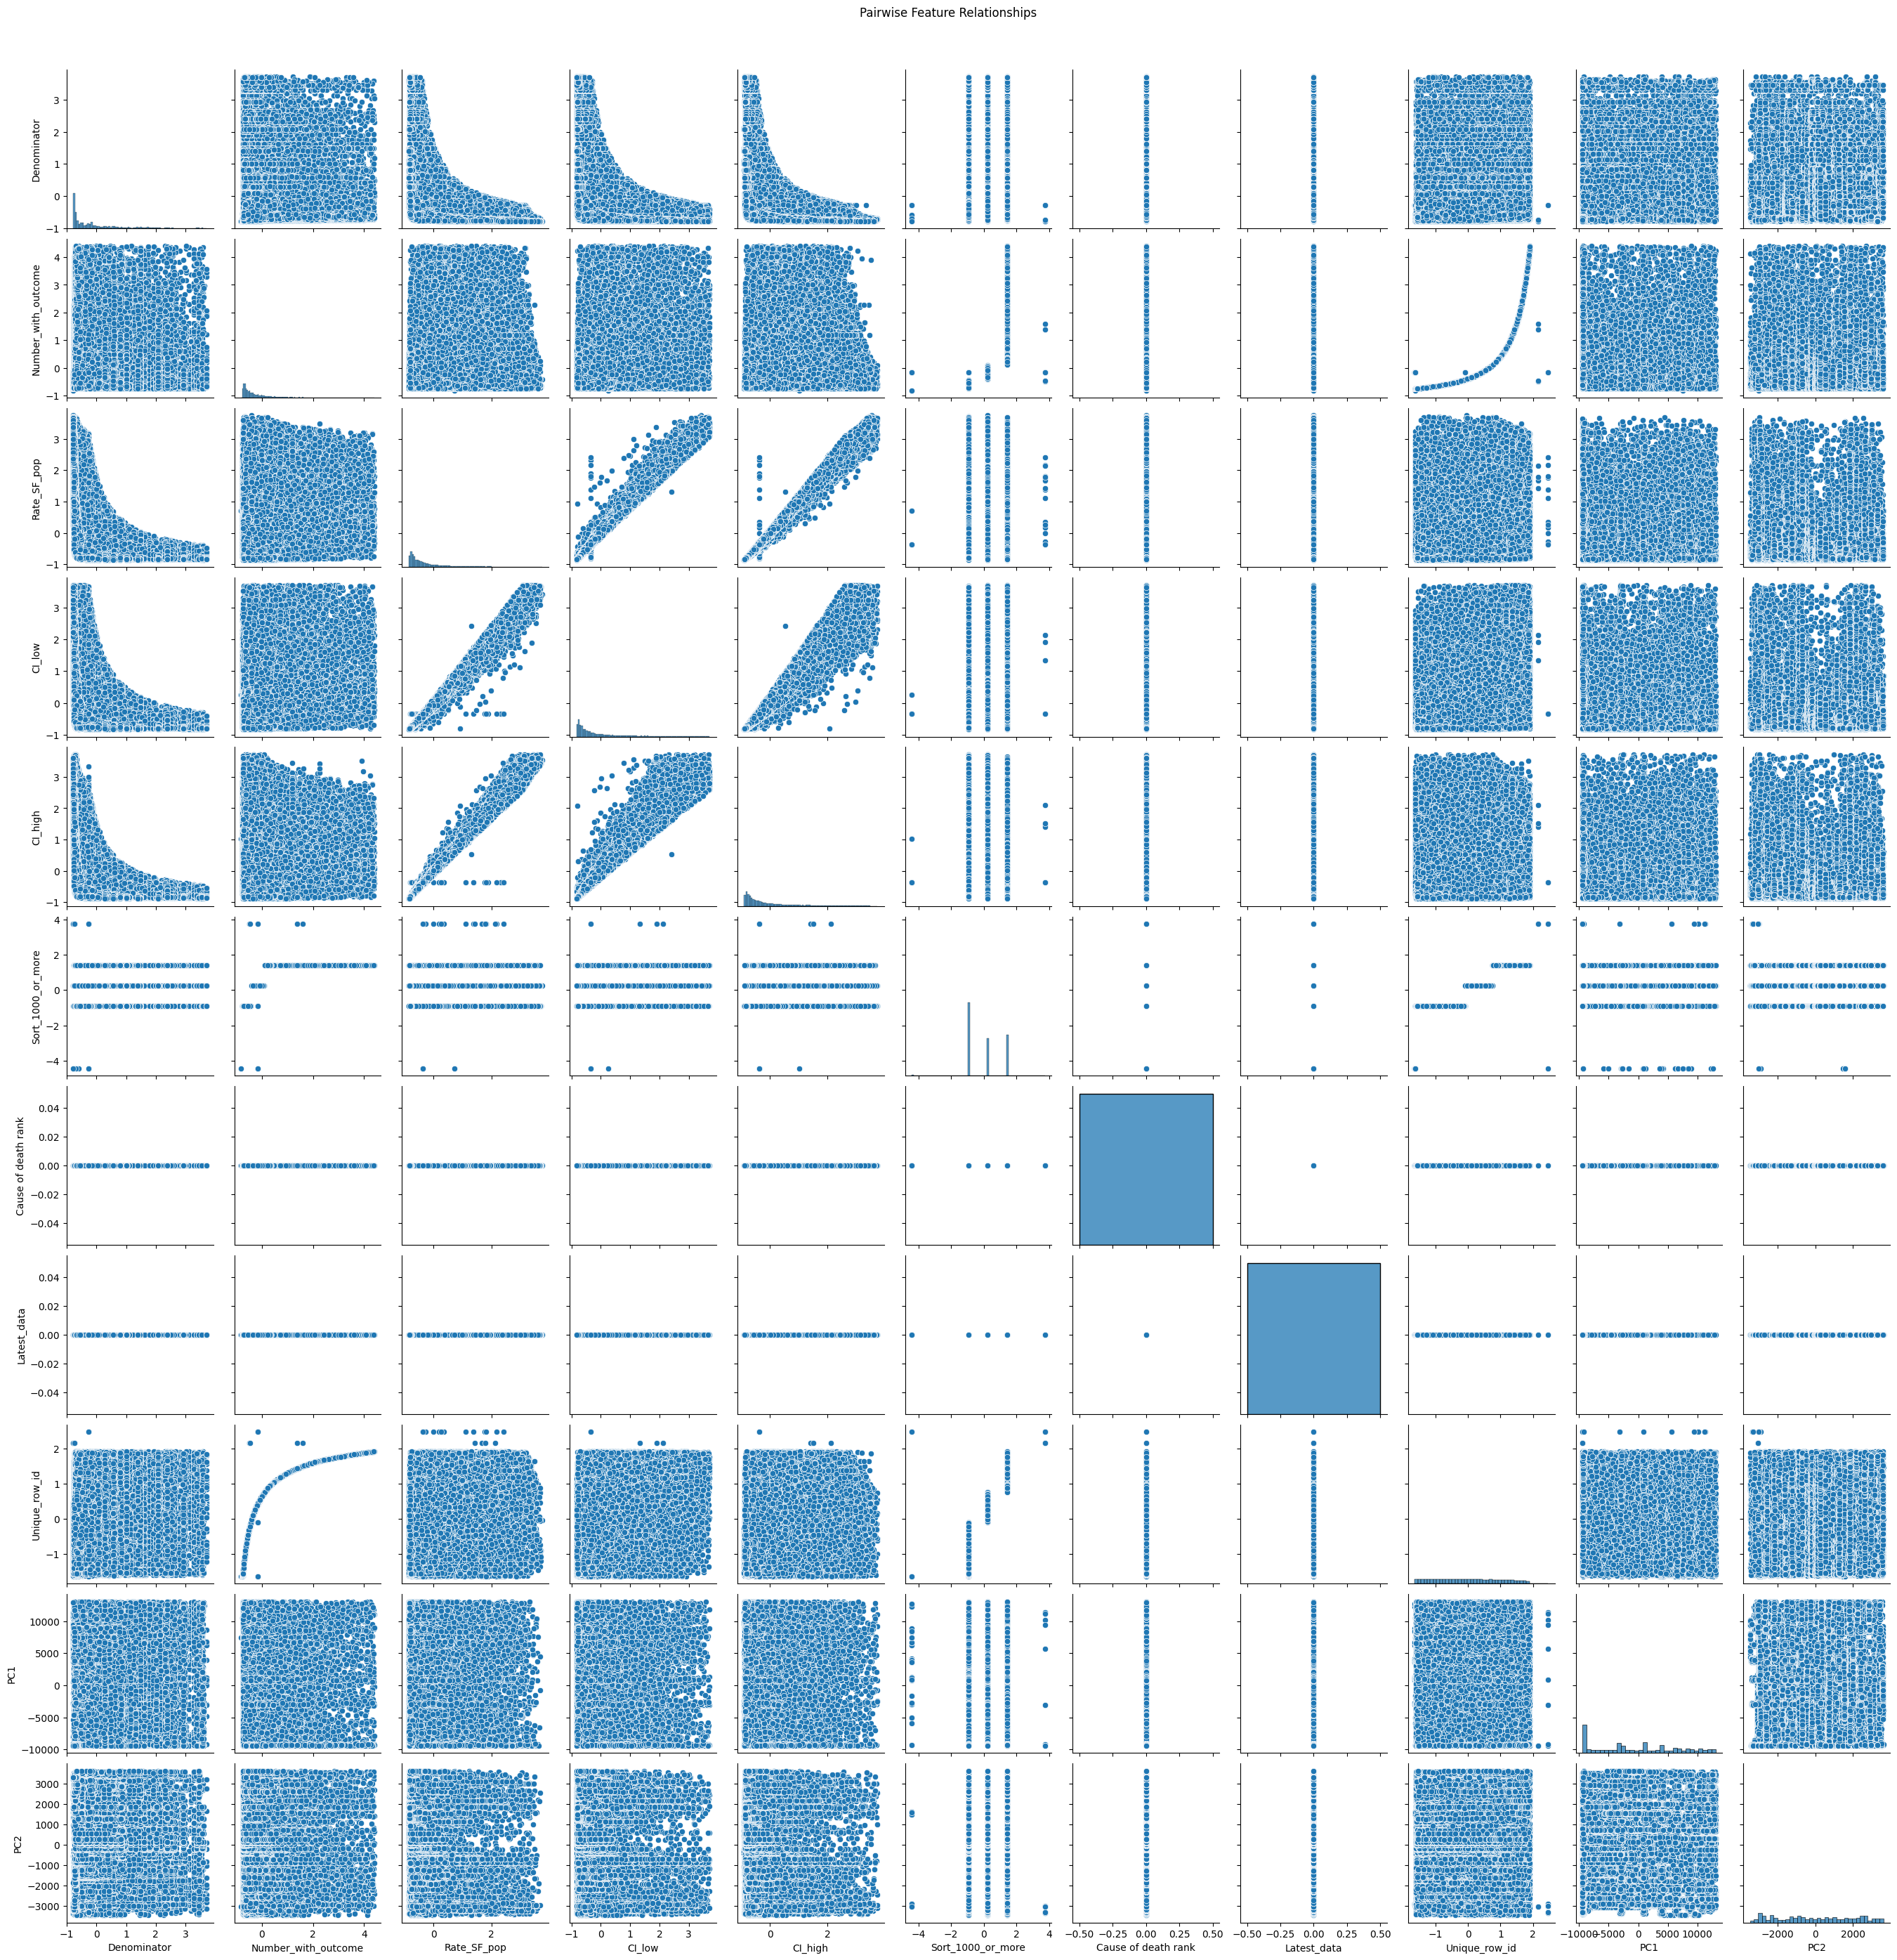

In [ ]:
#pairwise relations
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.pairplot(df[numerical_cols])
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()


/tmp/ipython-input-1607954946.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Year', y='Rate_SF_pop', estimator='mean', ci=None, marker='o')


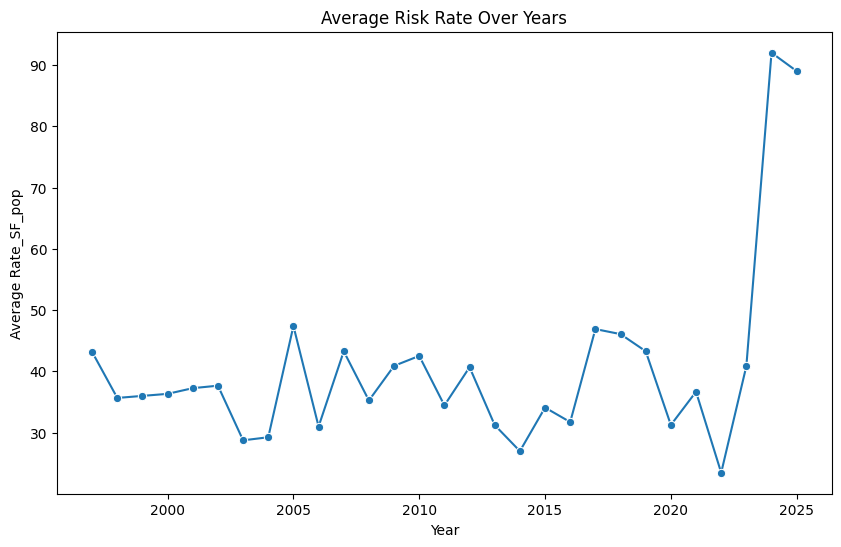

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
#Temporal Trend Diagnostics
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='Rate_SF_pop', estimator='mean', ci=None, marker='o')
plt.title("Average Risk Rate Over Years")
plt.xlabel("Year")
plt.ylabel("Average Rate_SF_pop")
plt.show()

Data Assessment

Missing Values (%):
 Age_group                       25.468146
Sex                             25.468146
Topic                           25.468146
Data_source                     25.468146
Health_condition-Data_source    25.468146
Period                          25.468146
Year                            25.468146
Denominator                     25.468146
Denominator_is                  25.468146
Number_with_outcome             25.468146
Numerator_is                    25.468146
Rate_95CI                       25.468146
Rate_SF_pop                     25.468146
CI_low                          25.468146
CI_high                         25.468146
Rate_is                         25.468146
Insurance                       25.468146
Zip_code                        25.468146
Race_ethnicity                  25.468146
Rate_title                      25.468146
Trend_title                     25.468146
Filter_1000_or_more             25.468146
Sort_1000_or_more               25.468146
Primary_Neigh

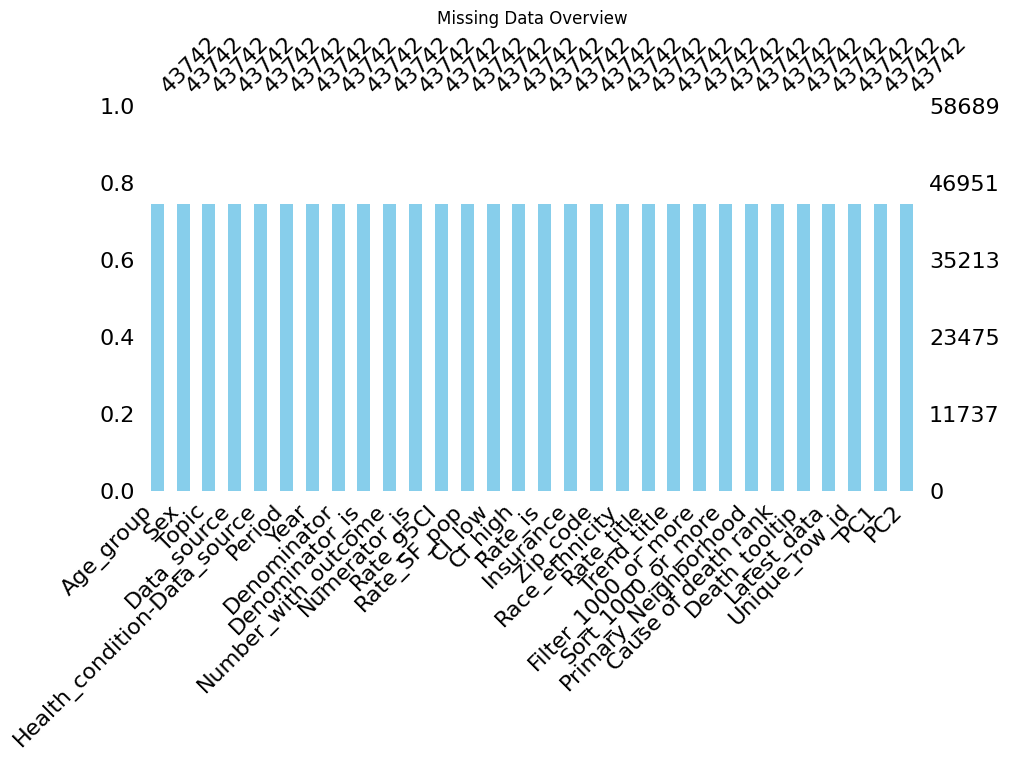

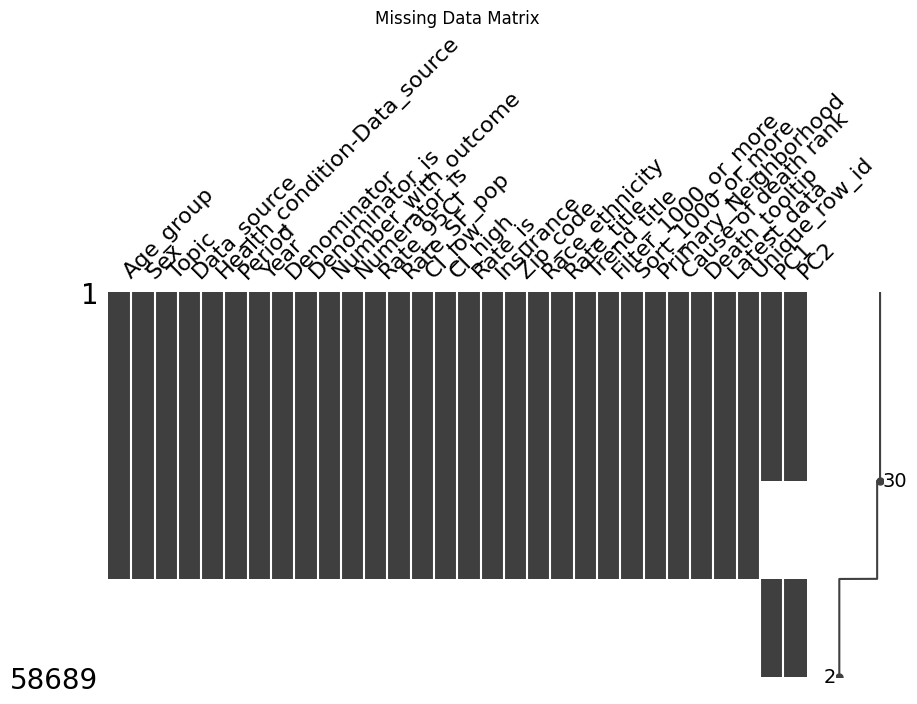

In [ ]:
#missing values
import missingno as msno
import matplotlib.pyplot as plt

# Percentage of missing values per column
missing_percentage = df.isnull().mean() * 100
print("Missing Values (%):\n", missing_percentage)

# Visualize missingness patterns
msno.bar(df, figsize=(10,5), color='skyblue')
plt.title("Missing Data Overview")
plt.show()

msno.matrix(df, figsize=(10,5))
plt.title("Missing Data Matrix")
plt.show()

# Optional: Visualize correlations of missingness
#msno.heatmap(df, figsize=(8,5))
#plt.title("Missingness Correlation Heatmap")
#plt.show()


In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Detect inconsistent categorical labels (e.g., capitalization, spacing)
for col in categorical_cols:
    print(f"Unique values in {col}: {df[col].unique()[:10]}")  # preview top categories

# Check numerical consistency
for col in numerical_cols:
    print(f"{col}: Min={df[col].min()}, Max={df[col].max()}")


Duplicate rows: 0
Unique values in Age_group: [ 0.  1.  2.  3.  4. 43.  5.  6.  7.  8.]
Unique values in Sex: [ 0.  2.  4.  1.  3. nan]
Unique values in Topic: [ 5.  7.  0.  2.  1.  9.  8.  3. 10.  6.]
Unique values in Data_source: [ 0.  1.  2.  4.  9. 11. 12.  8.  5. 13.]
Unique values in Health_condition-Data_source: [ 32.  33.  81. 117. 124. 189. 198. 228. 229. 230.]
Unique values in Period: [43. 47. 50. 52. 27. 38. 49. 22. 25. 29.]
Unique values in Denominator_is: [18. 10. 21.  9. 12. 22. 19. 17. 16.  8.]
Unique values in Numerator_is: [ 7. 10.  6.  4.  2.  8.  5.  1.  3.  0.]
Unique values in Rate_95CI: [ 10.  25.  31.  11.   2.  13.   3.  28.  20. 138.]
Unique values in Rate_is: [ 0.  1.  2.  4.  3. nan]
Unique values in Insurance: [ 0.  4.  3.  2.  1.  5. nan]
Unique values in Zip_code: [28. 17.  1. 11. 12.  0. 14.  4.  6. 10.]
Unique values in Race_ethnicity: [ 0.  1.  4. 11.  5.  3.  7.  9. 10.  2.]
Unique values in Rate_title: [1099. 1100. 1102. 1103. 1097. 1098. 1101. 1104. 

In [ ]:
# Check datatypes
print(df.dtypes)

# Check class balance for categorical variables like Race, Insurance
for col in categorical_cols:
    print(f"\nValue distribution for {col}:")
    print(df[col].value_counts(normalize=True) * 100)

# Basic numerical spread check
df[numerical_cols].describe()


Age_group                       float64
Sex                             float64
Topic                           float64
Data_source                     float64
Health_condition-Data_source    float64
Period                          float64
Year                            float64
Denominator                     float64
Denominator_is                  float64
Number_with_outcome             float64
Numerator_is                    float64
Rate_95CI                       float64
Rate_SF_pop                     float64
CI_low                          float64
CI_high                         float64
Rate_is                         float64
Insurance                       float64
Zip_code                        float64
Race_ethnicity                  float64
Rate_title                      float64
Trend_title                     float64
Filter_1000_or_more             float64
Sort_1000_or_more               float64
Primary_Neighborhood            float64
Cause of death rank             float64


,Denominator,Number_with_outcome,Rate_SF_pop,CI_low,CI_high,Sort_1000_or_more,Cause of death rank,Latest_data,Unique_row_id,PC1,PC2
count,4.374200e+04,4.374200e+04,4.374200e+04,4.374200e+04,4.374200e+04,4.374200e+04,43742.0,43742.0,4.374200e+04,4.374200e+04,4.374200e+04
mean,1.039613e-17,-9.551441e-17,-6.497579e-17,-3.378741e-17,5.198063e-17,1.416472e-16,0.0,0.0,-7.407240e-17,2.980777e-13,1.171020e-13
std,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,0.0,0.0,1.000011e+00,7.029585e+03,2.054598e+03
min,-7.857598e-01,-8.234719e-01,-8.614031e-01,-8.319299e-01,-8.922396e-01,-4.409263e+00,0.0,0.0,-1.649309e+00,-9.420608e+03,-3.469862e+03
25%,-7.171295e-01,-6.399682e-01,-7.021556e-01,-6.878668e-01,-7.103042e-01,-9.128769e-01,0.0,0.0,-8.638369e-01,-6.665422e+03,-1.926534e+03
50%,-4.163486e-01,-4.024928e-01,-4.190490e-01,-4.213501e-01,-4.152739e-01,2.525852e-01,0.0,0.0,-4.668562e-02,-1.454143e+02,-2.383789e+01
75%,3.372360e-01,1.804013e-01,3.123097e-01,2.827582e-01,3.370533e-01,1.418047e+00,0.0,0.0,8.263387e-01,6.179397e+03,1.845239e+03
max,3.715804e+00,4.400986e+00,3.744977e+00,3.706057e+00,3.720067e+00,3.748972e+00,0.0,0.0,2.467634e+00,1.308380e+04,3.624745e+03


In [ ]:
# Replace 'your_filename.csv' with a name you want
output_path = '/content/drive/MyDrive/Cleaned Data.csv'
df.to_csv(output_path, index=False)

print(f"✅ DataFrame saved to: {output_path}")


✅ DataFrame saved to: /content/drive/MyDrive/Cleaned Data.csv
